# Pandas

![Pandas](https://i.natgeofe.com/n/992e3500-31cc-4b2c-b590-98321b274951/panda-cubs-group.jpg "Group of baby pandas" )


# Pandas Data Frames

In [1]:
import pandas as pd


## Building a data frame

In [2]:
# We can build a data frame using a dictionary
my_dict = {'dogs' : [1,0,4,3,2],
           'cats' : [3,2,0,1,1]}
my_dict


{'dogs': [1, 0, 4, 3, 2], 'cats': [3, 2, 0, 1, 1]}

In [3]:
animals = pd.DataFrame(my_dict)
display(animals)

,dogs,cats
0,1,3
1,0,2
2,4,0
3,3,1
4,2,1


In [4]:
type(animals)

pandas.core.frame.DataFrame

In [5]:
animals?

In [6]:
# fetch second row
animals.iloc[1]

,1
dogs,0
cats,2


In [7]:
animals.loc[1]

,1
dogs,0
cats,2


In [8]:
type(animals.iloc[1])

pandas.core.series.Series

In [9]:
(
  animals
.iloc[2]
.iloc[0]
 )

np.int64(4)

In [10]:
animals

,dogs,cats
0,1,3
1,0,2
2,4,0
3,3,1
4,2,1


In [11]:
# Change the index
animals = pd.DataFrame(my_dict, index = ['Joe', 'Mary', 'Roger', 'David', 'Mikey'])
print(animals)

       dogs  cats
Joe       1     3
Mary      0     2
Roger     4     0
David     3     1
Mikey     2     1


In [12]:
animals.iloc[-1]

,Mikey
dogs,2
cats,1


In [13]:
animals.loc["Mikey"]

,Mikey
dogs,2
cats,1


### Your Turn
Create a data frame that looks like the table below. Name this data frame `movies`. Use the `Movie` column as your index.

Movie | Lead Actor | Times Watched
------|------------|--------------
Titanic|Leo DiCaprio|3
Die Hard|Bruce Willis|5
Back to the Future | Michael J. Fox | 15
Forrest Gump | Tom Hanks | NaN

Note: to add a `NaN` to your dataframe, you will need to do the following:
1. Run `import numpy as np`
2. Use `np.nan` in your dataframe.

In [14]:
# Solution
import numpy as np

movies_dict =  {
  'Lead Actor' : "Leo DiCaprio, Bruce Willis, Michael J. Fox, Tom Hanks".split(', '),
  'Times Watched' : [3, 5, 15, np.nan],
}
movies_dict


{'Lead Actor': ['Leo DiCaprio', 'Bruce Willis', 'Michael J. Fox', 'Tom Hanks'],
 'Times Watched': [3, 5, 15, nan]}

In [15]:
movies = pd.DataFrame(movies_dict, index = "Titanic,Die Hard,Back to the Future,Forrest Gump".split(',') )
movies


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [16]:
# Solution, alternative 1
# -- if you created Movie as a column
import numpy as np

movies_dict =  {
  'Movie':  "Titanic, Die Hard, Back to the Future, Forrest Gump".split(', '),
  'Lead Actor' : "Leo DiCaprio, Bruce Willis, Michael J. Fox, Tom Hanks".split(', '),
  'Times Watched' : [3, 5, 15, np.nan],
}
movies_dict


{'Movie': ['Titanic', 'Die Hard', 'Back to the Future', 'Forrest Gump'],
 'Lead Actor': ['Leo DiCaprio', 'Bruce Willis', 'Michael J. Fox', 'Tom Hanks'],
 'Times Watched': [3, 5, 15, nan]}

In [17]:
movies = pd.DataFrame(movies_dict)
movies


,Movie,Lead Actor,Times Watched
0,Titanic,Leo DiCaprio,3.0
1,Die Hard,Bruce Willis,5.0
2,Back to the Future,Michael J. Fox,15.0
3,Forrest Gump,Tom Hanks,NaN


In [18]:
movies.index = movies["Movie"]
movies


,Movie,Lead Actor,Times Watched
Movie,,,
Titanic,Titanic,Leo DiCaprio,3.0
Die Hard,Die Hard,Bruce Willis,5.0
Back to the Future,Back to the Future,Michael J. Fox,15.0
Forrest Gump,Forrest Gump,Tom Hanks,NaN


In [19]:
movies.drop(columns=["Movie"], inplace = True)
movies


,Lead Actor,Times Watched
Movie,,
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [20]:
movies.rename_axis(None, inplace=True)
movies


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [21]:
# Solution, alternative 2
movies_md = '''
Movie | Lead Actor | Times Watched
------|------------|--------------
Titanic|Leo DiCaprio|3
Die Hard|Bruce Willis|5
Back to the Future | Michael J. Fox | 15
Forrest Gump | Tom Hanks | NaN
'''
print(movies_md)



Movie | Lead Actor | Times Watched
------|------------|--------------
Titanic|Leo DiCaprio|3
Die Hard|Bruce Willis|5
Back to the Future | Michael J. Fox | 15
Forrest Gump | Tom Hanks | NaN



In [22]:
import markdown
from io import StringIO

html_table = markdown.markdown(movies_md, extensions=['tables'])
df = pd.read_html(StringIO(html_table))[0].set_index(["Movie"]).rename_axis(None)
df


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


## Creating a data frame by reading in a CSV

In [23]:
# Read in CSV
url = "http://ddc-datascience.s3.amazonaws.com/Home_Data.csv"
home_data = pd.read_csv(url, usecols=range(9))


In [24]:
# Look at first 5 rows
home_data.head(5)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl


## Viewing/Understanding Data

In [25]:
# View the first 5 rows
home_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl


In [26]:
home_data.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl


In [27]:
# See the dimension of your data frame
home_data.shape

(1460, 9)

In [28]:
# See the information about each column in your data frame
home_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Id           1460 non-null   int64  
 1   MSSubClass   1460 non-null   int64  
 2   MSZoning     1460 non-null   object 
 3   LotFrontage  1201 non-null   float64
 4   LotArea      1460 non-null   int64  
 5   Street       1460 non-null   object 
 6   Alley        91 non-null     object 
 7   LotShape     1460 non-null   object 
 8   LandContour  1460 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 102.8+ KB


In [29]:
# Get summary statistics about your data frame
home_data.describe(include = "all" )


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460
unique,NaN,NaN,5,NaN,NaN,2,2,4,4
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN


In [30]:
# See the names of the columns
home_data.columns


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour'],
      dtype='object')

In [31]:
home_data.columns.to_list()

['Id',
 'MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'Street',
 'Alley',
 'LotShape',
 'LandContour']

### Your Turn
1. Use the `info()` and `describe()` methods on `movies` data frame.
2. Find another method that can be used on dataframes. Look at the help documentation for that method. Write a brief description of what that method does.

In [32]:
movies


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [33]:
# Solution
movies.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, Titanic to Forrest Gump
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Lead Actor     4 non-null      object 
 1   Times Watched  3 non-null      float64
dtypes: float64(1), object(1)
memory usage: 268.0+ bytes


In [34]:
# Solution
movies.describe(include = "all")


,Lead Actor,Times Watched
count,4,3.000000
unique,4,NaN
top,Leo DiCaprio,NaN
freq,1,NaN
mean,NaN,7.666667
std,NaN,6.429101
min,NaN,3.000000
25%,NaN,4.000000
50%,NaN,5.000000
75%,NaN,10.000000


In [35]:
# Solution
movies.transpose()


,Titanic,Die Hard,Back to the Future,Forrest Gump
Lead Actor,Leo DiCaprio,Bruce Willis,Michael J. Fox,Tom Hanks
Times Watched,3.0,5.0,15.0,NaN


In [36]:
help(movies.transpose)


Help on method transpose in module pandas.core.frame:

transpose(*args, copy: 'bool' = False) -> 'DataFrame' method of pandas.core.frame.DataFrame instance
    Transpose index and columns.

    Reflect the DataFrame over its main diagonal by writing rows as columns
    and vice-versa. The property :attr:`.T` is an accessor to the method
    :meth:`transpose`.

    Parameters
    ----------
    *args : tuple, optional
        Accepted for compatibility with NumPy.
    copy : bool, default False
        Whether to copy the data after transposing, even for DataFrames
        with a single dtype.

        Note that a copy is always required for mixed dtype DataFrames,
        or for DataFrames with any extension types.

        .. note::
            The `copy` keyword will change behavior in pandas 3.0.
            `Copy-on-Write
            <https://pandas.pydata.org/docs/dev/user_guide/copy_on_write.html>`__
            will be enabled by default, which means that all methods with a
    

In [37]:
# Solution
movies.index


Index(['Titanic', 'Die Hard', 'Back to the Future', 'Forrest Gump'], dtype='object')

In [38]:
help(movies.to_csv)

Help on method to_csv in module pandas.core.generic:

to_csv(path_or_buf: 'FilePath | WriteBuffer[bytes] | WriteBuffer[str] | None' = None, *, sep: 'str' = ',', na_rep: 'str' = '', float_format: 'str | Callable | None' = None, columns: 'Sequence[Hashable] | None' = None, header: 'bool_t | list[str]' = True, index: 'bool_t' = True, index_label: 'IndexLabel | None' = None, mode: 'str' = 'w', encoding: 'str | None' = None, compression: 'CompressionOptions' = 'infer', quoting: 'int | None' = None, quotechar: 'str' = '"', lineterminator: 'str | None' = None, chunksize: 'int | None' = None, date_format: 'str | None' = None, doublequote: 'bool_t' = True, escapechar: 'str | None' = None, decimal: 'str' = '.', errors: 'OpenFileErrors' = 'strict', storage_options: 'StorageOptions | None' = None) -> 'str | None' method of pandas.core.frame.DataFrame instance
    Write object to a comma-separated values (csv) file.

    Parameters
    ----------
    path_or_buf : str, path object, file-like object

In [39]:
help(movies.to_numpy)

Help on method to_numpy in module pandas.core.frame:

to_numpy(dtype: 'npt.DTypeLike | None' = None, copy: 'bool' = False, na_value: 'object' = <no_default>) -> 'np.ndarray' method of pandas.core.frame.DataFrame instance
    Convert the DataFrame to a NumPy array.

    By default, the dtype of the returned array will be the common NumPy
    dtype of all types in the DataFrame. For example, if the dtypes are
    ``float16`` and ``float32``, the results dtype will be ``float32``.
    This may require copying data and coercing values, which may be
    expensive.

    Parameters
    ----------
    dtype : str or numpy.dtype, optional
        The dtype to pass to :meth:`numpy.asarray`.
    copy : bool, default False
        Whether to ensure that the returned value is not a view on
        another array. Note that ``copy=False`` does not *ensure* that
        ``to_numpy()`` is no-copy. Rather, ``copy=True`` ensure that
        a copy is made, even if not strictly necessary.
    na_value : A

In [40]:
help(movies.asfreq)

Help on method asfreq in module pandas.core.generic:

asfreq(freq: 'Frequency', method: 'FillnaOptions | None' = None, how: "Literal['start', 'end'] | None" = None, normalize: 'bool_t' = False, fill_value: 'Hashable | None' = None) -> 'Self' method of pandas.core.frame.DataFrame instance
    Convert time series to specified frequency.

    Returns the original data conformed to a new index with the specified
    frequency.

    If the index of this Series/DataFrame is a :class:`~pandas.PeriodIndex`, the new index
    is the result of transforming the original index with
    :meth:`PeriodIndex.asfreq <pandas.PeriodIndex.asfreq>` (so the original index
    will map one-to-one to the new index).

    Otherwise, the new index will be equivalent to ``pd.date_range(start, end,
    freq=freq)`` where ``start`` and ``end`` are, respectively, the first and
    last entries in the original index (see :func:`pandas.date_range`). The
    values corresponding to any timesteps in the new index which

In [41]:
help(movies.bfill)

Help on method bfill in module pandas.core.generic:

bfill(*, axis: 'None | Axis' = None, inplace: 'bool_t' = False, limit: 'None | int' = None, limit_area: "Literal['inside', 'outside'] | None" = None, downcast: 'dict | None | lib.NoDefault' = <no_default>) -> 'Self | None' method of pandas.core.frame.DataFrame instance
    Fill NA/NaN values by using the next valid observation to fill the gap.

    Parameters
    ----------
    axis : {0 or 'index'} for Series, {0 or 'index', 1 or 'columns'} for DataFrame
        Axis along which to fill missing values. For `Series`
        this parameter is unused and defaults to 0.
    inplace : bool, default False
        If True, fill in-place. Note: this will modify any
        other views on this object (e.g., a no-copy slice for a column in a
        DataFrame).
    limit : int, default None
        If method is specified, this is the maximum number of consecutive
        NaN values to forward/backward fill. In other words, if there is
       

In [42]:
help(movies.index)


Help on Index in module pandas.core.indexes.base object:

class Index(pandas.core.base.IndexOpsMixin, pandas.core.base.PandasObject)
 |  Index(data=None, dtype=None, copy: 'bool' = False, name=None, tupleize_cols: 'bool' = True) -> 'Self'
 |
 |  Immutable sequence used for indexing and alignment.
 |
 |  The basic object storing axis labels for all pandas objects.
 |
 |  .. versionchanged:: 2.0.0
 |
 |     Index can hold all numpy numeric dtypes (except float16). Previously only
 |     int64/uint64/float64 dtypes were accepted.
 |
 |  Parameters
 |  ----------
 |  data : array-like (1-dimensional)
 |  dtype : str, numpy.dtype, or ExtensionDtype, optional
 |      Data type for the output Index. If not specified, this will be
 |      inferred from `data`.
 |      See the :ref:`user guide <basics.dtypes>` for more usages.
 |  copy : bool, default False
 |      Copy input data.
 |  name : object
 |      Name to be stored in the index.
 |  tupleize_cols : bool (default: True)
 |      When Tr

In [43]:
help(movies.at_time)

Help on method at_time in module pandas.core.generic:

at_time(time, asof: 'bool_t' = False, axis: 'Axis | None' = None) -> 'Self' method of pandas.core.frame.DataFrame instance
    Select values at particular time of day (e.g., 9:30AM).

    Parameters
    ----------
    time : datetime.time or str
        The values to select.
    axis : {0 or 'index', 1 or 'columns'}, default 0
        For `Series` this parameter is unused and defaults to 0.

    Returns
    -------
    Series or DataFrame

    Raises
    ------
    TypeError
        If the index is not  a :class:`DatetimeIndex`

    See Also
    --------
    between_time : Select values between particular times of the day.
    first : Select initial periods of time series based on a date offset.
    last : Select final periods of time series based on a date offset.
    DatetimeIndex.indexer_at_time : Get just the index locations for
        values at particular time of the day.

    Examples
    --------
    >>> i = pd.date_range('

In [44]:
help(movies.map)

Help on method map in module pandas.core.frame:

map(func: 'PythonFuncType', na_action: 'str | None' = None, **kwargs) -> 'DataFrame' method of pandas.core.frame.DataFrame instance
    Apply a function to a Dataframe elementwise.

    .. versionadded:: 2.1.0

       DataFrame.applymap was deprecated and renamed to DataFrame.map.

    This method applies a function that accepts and returns a scalar
    to every element of a DataFrame.

    Parameters
    ----------
    func : callable
        Python function, returns a single value from a single value.
    na_action : {None, 'ignore'}, default None
        If 'ignore', propagate NaN values, without passing them to func.
    **kwargs
        Additional keyword arguments to pass as keywords arguments to
        `func`.

    Returns
    -------
    DataFrame
        Transformed DataFrame.

    See Also
    --------
    DataFrame.apply : Apply a function along input axis of DataFrame.
    DataFrame.replace: Replace values given in `to_repla

## Cleaning Data

In [45]:
home_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl


In [46]:
# Dealing with Missing Values
home_data.isnull().head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
0,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,True,False,False


In [47]:
home_data.isnull().sum()


,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
Street,0
Alley,1369
LotShape,0
LandContour,0


In [48]:
# Let's drop the columns with NaNs.
# First, we need to create a copy of our data frame
home_data_clean = home_data.copy()
home_data_clean.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl


In [49]:
# axis = 1 tells the function to drop a column instead of a row
# in place tells the function to alter home_data_clean instead of returning a new data frame
# home_data_clean.dropna(axis = "columns", inplace=True)
home_data_clean.dropna(axis = 1, inplace=True)
home_data_clean.head()

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour
0,1,60,RL,8450,Pave,Reg,Lvl
1,2,20,RL,9600,Pave,Reg,Lvl
2,3,60,RL,11250,Pave,IR1,Lvl
3,4,70,RL,9550,Pave,IR1,Lvl
4,5,60,RL,14260,Pave,IR1,Lvl


In [50]:
home_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl


### Your Turn
Make a copy of your `movies` data frame. Save it as `movies_clean`.
Drop the **row** that contains a NaN.

In [51]:
movies


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [52]:
# Solution
movies_clean = movies.copy()
movies_clean


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [53]:
# Solution
movies_clean.dropna(
  inplace = True,
  axis="rows",
  # axis=0,
)

In [54]:
movies_clean

,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0


In [55]:
movies.dropna?


## Imputation
Let's say we didn't want to just drop the LotFrontage column as it only had 259 NaNs.

In [56]:
# Make a copy
home_data_impute = home_data.copy()
home_data_impute.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl


In [57]:
# Remove only the Alley column
# home_data_impute.drop(labels ='Alley', axis = "columns", inplace = True)
home_data_impute.drop(labels ='Alley', axis = 1, inplace = True)
home_data_impute.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour
0,1,60,RL,65.0,8450,Pave,Reg,Lvl
1,2,20,RL,80.0,9600,Pave,Reg,Lvl
2,3,60,RL,68.0,11250,Pave,IR1,Lvl
3,4,70,RL,60.0,9550,Pave,IR1,Lvl
4,5,60,RL,84.0,14260,Pave,IR1,Lvl


In [58]:
# Check to see our NaNs
home_data_impute.isnull().sum().sort_values()

,0
Id,0
MSSubClass,0
MSZoning,0
LotArea,0
LotShape,0
Street,0
LandContour,0
LotFrontage,259


In [59]:
home_data_impute['LotFrontage']

,LotFrontage
0,65.0
1,80.0
2,68.0
3,60.0
4,84.0
...,...
1455,62.0
1456,85.0
1457,66.0
1458,68.0


In [60]:
# Replace the NaNs in LotFrontage with the mean lot frontage amount
lot_frontage_mean = home_data_impute['LotFrontage'].mean()
lot_frontage_mean

np.float64(70.04995836802665)

In [61]:
home_data_impute.fillna(lot_frontage_mean, inplace = True)
home_data_impute.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
LotShape,0
LandContour,0


In [62]:
home_data_impute.describe( include = "all")

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour
count,1460.000000,1460.000000,1460,1460.000000,1460.000000,1460,1460,1460
unique,NaN,NaN,5,NaN,NaN,2,4,4
top,NaN,NaN,RL,NaN,NaN,Pave,Reg,Lvl
freq,NaN,NaN,1151,NaN,NaN,1454,925,1311
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN
std,421.610009,42.300571,NaN,22.024023,9981.264932,NaN,NaN,NaN
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN
25%,365.750000,20.000000,NaN,60.000000,7553.500000,NaN,NaN,NaN
50%,730.500000,50.000000,NaN,70.049958,9478.500000,NaN,NaN,NaN
75%,1095.250000,70.000000,NaN,79.000000,11601.500000,NaN,NaN,NaN


### Your Turn
Make another copy of your original `movies` data frame and save it as `movies_impute`. Replace the NaN with a 0.

In [63]:
movies


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [64]:
# Solution
movies_impute = movies.copy()
movies_impute


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [65]:
movies_impute.fillna(
    0,
    # inplace=True,
    )

,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,0.0


In [66]:
movies_impute


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [67]:
movies_impute.fillna(
    0,
    inplace=True
    )

In [68]:
movies_impute

,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,0.0


## Indexing by Column

In [69]:
# We can index a column using square brackets and the column name
street_col = home_data_impute['Street']
street_col.head()

,Street
0,Pave
1,Pave
2,Pave
3,Pave
4,Pave


In [70]:
type(street_col)

pandas.core.series.Series

In [71]:
# We can index multiple columns using a list of column names
multiple_cols = home_data_impute[['Street', 'LotShape']]
multiple_cols.head()

,Street,LotShape
0,Pave,Reg
1,Pave,Reg
2,Pave,IR1
3,Pave,IR1
4,Pave,IR1


In [72]:
type(multiple_cols)

pandas.core.frame.DataFrame

In [73]:
street_col = home_data_impute[['Street']]
street_col.head()

,Street
0,Pave
1,Pave
2,Pave
3,Pave
4,Pave


In [74]:
type(street_col)

pandas.core.frame.DataFrame

### Your Turn
Index the `Lead Actor` column of your `movies_impute` data frame. Save it to a variable called `actors`. Print out `actors`. Also, display the data type of `actors`.

In [79]:
# Solution
actors = movies_impute["Lead Actor"]
actors


,Lead Actor
Titanic,Leo DiCaprio
Die Hard,Bruce Willis
Back to the Future,Michael J. Fox
Forrest Gump,Tom Hanks


In [80]:
# Solution
type(actors)


pandas.core.series.Series

In [81]:
# notice two square brackets
actors = movies_impute[["Lead Actor"]]
actors


,Lead Actor
Titanic,Leo DiCaprio
Die Hard,Bruce Willis
Back to the Future,Michael J. Fox
Forrest Gump,Tom Hanks


In [82]:
type(actors)


pandas.core.frame.DataFrame

## Indexing by Row
We can index rows in two ways:

- .loc - locates by name
- .iloc- locates by numerical index

In [83]:
# Let's take a look at the animals data frame we created earlier
animals

,dogs,cats
Joe,1,3
Mary,0,2
Roger,4,0
David,3,1
Mikey,2,1


In [84]:
# Index using loc
animals.loc['Roger']

,Roger
dogs,4
cats,0


In [85]:
# Index using iloc
animals.iloc[2]

,Roger
dogs,4
cats,0


In [86]:
# We can also slice!
animals.loc['Roger':'Mikey'] # Note - the stop point in .loc is inclusive

,dogs,cats
Roger,4,0
David,3,1
Mikey,2,1


In [87]:
animals.iloc[2:4] # The stop point in .iloc is not inclusive

,dogs,cats
Roger,4,0
David,3,1


In [88]:
animals.iloc[2:4]['dogs']

,dogs
Roger,4
David,3


In [89]:
( animals.iloc[2:4] )['dogs']

,dogs
Roger,4
David,3


In [90]:
( ( animals ).iloc[2:4] )['dogs']

,dogs
Roger,4
David,3


In [91]:
animals['dogs'].iloc[2:4]

,dogs
Roger,4
David,3


In [92]:
pd.DataFrame(animals['dogs'].iloc[2:4])

,dogs
Roger,4
David,3


In [93]:
animals[['dogs']].iloc[2:4]

,dogs
Roger,4
David,3


### Your Turn
1. Index the row for `Back to the Future` from the `movies` data frame using .loc and iloc.
2. Use a slice to index the rows for `Back to the Future` and `Forrest Gump`.

In [103]:
movies


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [104]:
# Solution
movies.loc["Back to the Future"]


,Back to the Future
Lead Actor,Michael J. Fox
Times Watched,15.0


In [105]:
movies.iloc[2]


,Back to the Future
Lead Actor,Michael J. Fox
Times Watched,15.0


In [106]:
movies.iloc[-2]


,Back to the Future
Lead Actor,Michael J. Fox
Times Watched,15.0


In [112]:
# Solution
movies.iloc[2:]


,Lead Actor,Times Watched
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [108]:
movies.iloc[-2:]


,Lead Actor,Times Watched
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [109]:
movies.loc["Back to the Future":]


,Lead Actor,Times Watched
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [110]:
movies.loc["Back to the Future":"Forrest Gump"]


,Lead Actor,Times Watched
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


## Conditional Selections

In [113]:
animals

,dogs,cats
Joe,1,3
Mary,0,2
Roger,4,0
David,3,1
Mikey,2,1


In [114]:
# We can use conditional statements to return booleans
animals['dogs'] == 4

,dogs
Joe,False
Mary,False
Roger,True
David,False
Mikey,False


In [115]:
# We can then use those booleans to index our data frame
filter = ( animals['dogs'] == 4 )
animals[ filter ]


,dogs,cats
Roger,4,0


In [116]:
# Another example
animals[ animals['cats'] > 1 ]

,dogs,cats
Joe,1,3
Mary,0,2


In [117]:
# A third example!
# Two things to note - we have to put parenthesis around each conditional statement
# and we have to use the '&' symbol instead of the word 'and'
animals[(animals['cats'] > 1) & (animals['dogs'] < 1)]


,dogs,cats
Mary,0,2


In [135]:
filter1 = (animals['cats'] > 1)
filter1
filter2 = (animals['dogs'] < 1)
filter2
filter3 = filter1 & filter2
filter3

animals[filter3]

,dogs,cats
Mary,0,2


In [138]:
animals[ filter1 + filter2]

,dogs,cats
Joe,1,3
Mary,0,2


In [145]:
pd.concat([filter1, filter2, filter1 & filter2, filter1 + filter2 ], axis=1)

,cats,dogs,0,1
Joe,True,False,False,True
Mary,True,True,True,True
Roger,False,False,False,False
David,False,False,False,False
Mikey,False,False,False,False


### Your Turn
Use a conditional statement to return the following from your `movies_impute` data frame:
1. Movies with Bruce Willis as the lead actor
2. Movies that have been watched more than 4 times

In [127]:
movies_impute


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,0.0


In [134]:
# Solution
filter = ( movies_impute["Lead Actor"] == "Bruce Willis" )
display( filter )
movies_impute[ filter ]


,Lead Actor
Titanic,False
Die Hard,True
Back to the Future,False
Forrest Gump,False


,Lead Actor,Times Watched
Die Hard,Bruce Willis,5.0


In [131]:
# Solution
filter = ( movies_impute["Times Watched"] > 4 )
filter

movies_impute[ filter ]


,Lead Actor,Times Watched
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0


# ==== Start Here ====


## Adding a Column

In [146]:
animals


,dogs,cats
Joe,1,3
Mary,0,2
Roger,4,0
David,3,1
Mikey,2,1


In [148]:
# We can easily add a column to our data frame
animals['chickens'] = [1,0,0,4,5]
animals

,dogs,cats,chickens
Joe,1,3,1
Mary,0,2,0
Roger,4,0,0
David,3,1,4
Mikey,2,1,5


In [149]:
# Add a single value to all rows, i.e. broadcasting
animals['ducks'] = 20
animals

,dogs,cats,chickens,ducks
Joe,1,3,1,20
Mary,0,2,0,20
Roger,4,0,0,20
David,3,1,4,20
Mikey,2,1,5,20


In [150]:
# Calculations
animals["Total"] = animals["dogs"] + animals["cats"] + animals["chickens"] + animals["ducks"]
animals

,dogs,cats,chickens,ducks,Total
Joe,1,3,1,20,25
Mary,0,2,0,20,22
Roger,4,0,0,20,24
David,3,1,4,20,28
Mikey,2,1,5,20,28


In [151]:
animals["all"] = animals.sum(axis = 1)
animals

,dogs,cats,chickens,ducks,Total,all
Joe,1,3,1,20,25,50
Mary,0,2,0,20,22,44
Roger,4,0,0,20,24,48
David,3,1,4,20,28,56
Mikey,2,1,5,20,28,56


In [152]:
animals.sum(axis = "columns")

,0
Joe,100
Mary,88
Roger,96
David,112
Mikey,112


## Adding a Row

In [154]:
# Similarly, we can add a row to our data frame
animals.loc['Nevin'] = [1,0,0,4,5,10]
animals

,dogs,cats,chickens,ducks,Total,all
Joe,1,3,1,20,25,50
Mary,0,2,0,20,22,44
Roger,4,0,0,20,24,48
David,3,1,4,20,28,56
Mikey,2,1,5,20,28,56
Nevin,1,0,0,4,5,10


### Your Turn
1. Add a column named `Rating` to your `movies_impute` data frame that gives your rating of the movie on a scale from 1-10 (where 10 is the best).
2. Add a row to your `movies_impute` data frame with the information for another movie.

In [167]:
movies_impute


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,0.0


In [168]:
# backup movies_impute
movies_impute_bak = movies_impute.copy()
movies_impute_bak


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,0.0


In [169]:
# restore movies_impute
movies_impute = movies_impute_bak.copy()
movies_impute


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,0.0


In [170]:
# Solution
movies_impute["Rating"] = [1, 8, 8, 8]
movies_impute


,Lead Actor,Times Watched,Rating
Titanic,Leo DiCaprio,3.0,1
Die Hard,Bruce Willis,5.0,8
Back to the Future,Michael J. Fox,15.0,8
Forrest Gump,Tom Hanks,0.0,8


In [171]:
# Solution
movies_impute.loc["This is Spinal Tap"] = ["Christopher Guest", 10_000, 11 ]
movies_impute


,Lead Actor,Times Watched,Rating
Titanic,Leo DiCaprio,3.0,1
Die Hard,Bruce Willis,5.0,8
Back to the Future,Michael J. Fox,15.0,8
Forrest Gump,Tom Hanks,0.0,8
This is Spinal Tap,Christopher Guest,10000.0,11


## A Quick Intro to Plotting Using Pandas

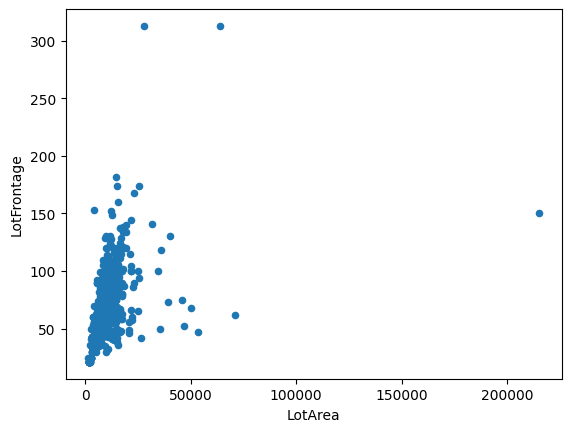

In [172]:
home_data.plot(
  kind = 'scatter',
     x = 'LotArea',
     y = 'LotFrontage',
) ;


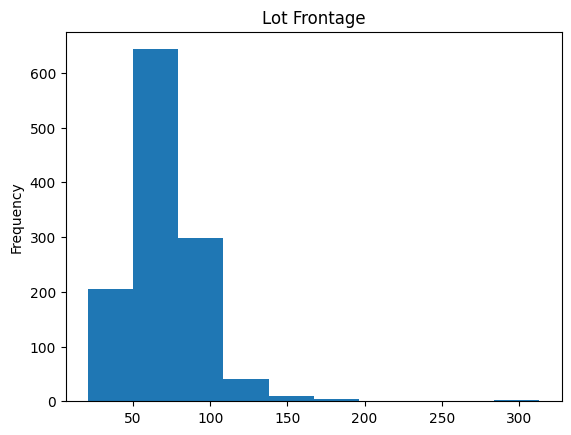

In [173]:
home_data['LotFrontage'].plot(kind = 'hist', title = 'Lot Frontage') ;

In [174]:
# Note positive skew, i.e mean > median ( 50% )
home_data[['LotFrontage']].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
LotFrontage,1201.0,70.049958,24.284752,21.0,59.0,69.0,80.0,313.0


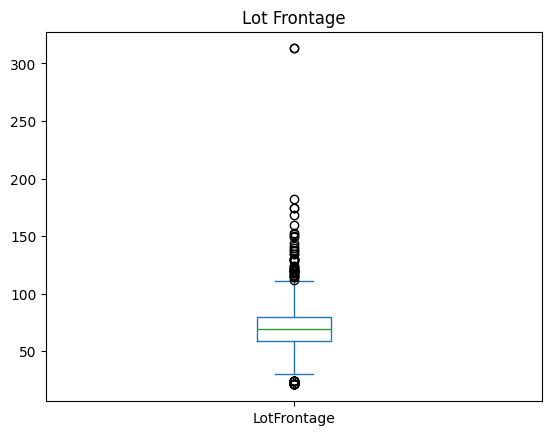

In [175]:
home_data['LotFrontage'].plot(kind = 'box', title = 'Lot Frontage') ;

### Your Turn
Create a scatter plot of your `Rating` column versus your `Times Watched` column from you `movies_impute` data frame.

In [178]:
movies_impute


,Lead Actor,Times Watched,Rating
Titanic,Leo DiCaprio,3.0,1
Die Hard,Bruce Willis,5.0,8
Back to the Future,Michael J. Fox,15.0,8
Forrest Gump,Tom Hanks,0.0,8
This is Spinal Tap,Christopher Guest,10000.0,11


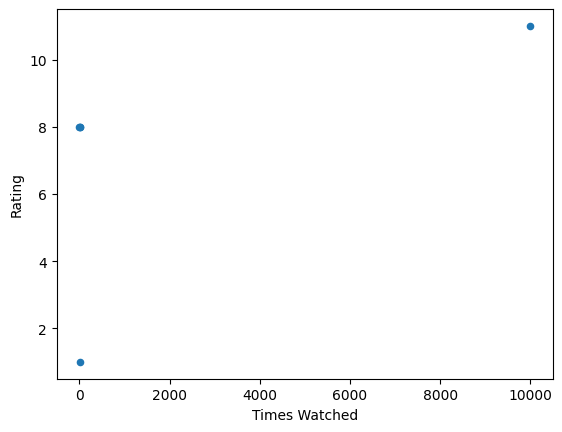

In [180]:
# Solution
movies_impute.plot(
  kind = 'scatter',
     y = 'Rating',
     x = 'Times Watched',
) ;
